In [7]:
# Required libraries for data preprocessing, class imbalance handling,
# decision tree modeling, and performance evaluation
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from category_encoders import OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler



warnings.simplefilter(action = 'ignore', category = FutureWarning)

In [8]:
# Function to load dataset and set 'id' as index
def wrangle(filepath):
    df = pd.read_csv(filepath).set_index('id')


    return df

In [9]:
# Load dataset, check dimensions, and preview first 5 rows
df = wrangle("/content/drive/MyDrive/dataset/healthcare-dataset-stroke-data.csv")
print(df.shape)
df.head(5)

(5110, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


✅ Exploratory Data Analysis (EDA)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5110 entries, 9046 to 44679
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 479.1+ KB


In [11]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [12]:
df.isna().sum()/len(df) *100

,0
gender,0.000000
age,0.000000
hypertension,0.000000
heart_disease,0.000000
ever_married,0.000000
work_type,0.000000
Residence_type,0.000000
avg_glucose_level,0.000000
bmi,3.933464
smoking_status,0.000000


In [13]:
df['gender'].value_counts()

,count
gender,
Female,2994
Male,2115
Other,1


In [14]:
df['bmi'].value_counts()

,count
bmi,
28.7,41
28.4,38
27.7,37
27.6,37
26.7,37
...,...
47.9,1
13.0,1
13.9,1


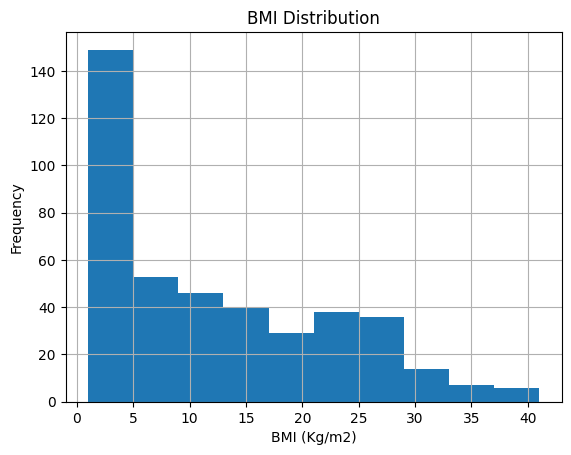

In [15]:
#BMI is having missing numbers
fig, ax = plt.subplots()
df['bmi'].value_counts().plot(kind = 'hist')
plt.xlabel('BMI (Kg/m2)')
plt.title('BMI Distribution')
plt.grid()

#median is used to fill in

Examine target variable distribution to assess class imbalance

In [16]:
df['stroke'].value_counts(normalize = True)

,proportion
stroke,
0,0.951272
1,0.048728


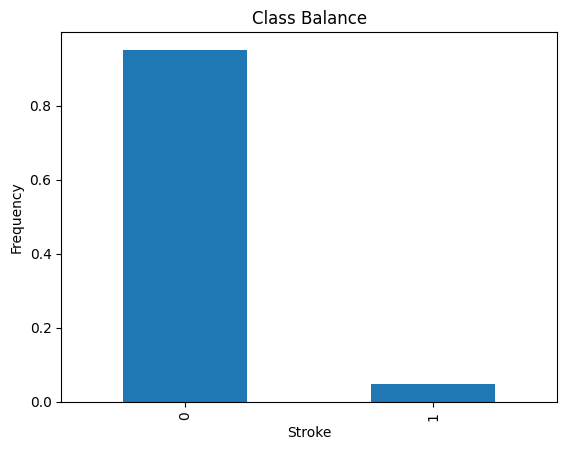

In [17]:
# Plot class balance
df['stroke'].value_counts(normalize = True).plot(kind = 'bar')
plt.xlabel('Stroke')
plt.ylabel('Frequency')
plt.title('Class Balance')
plt.show()

this shows us that we have an imbalanced dataset, where our majority class is far bigger than our minority class.

In [18]:
#check correlation
corr = df.select_dtypes(include = 'number').corr()
corr

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.000000,0.276398,0.263796,0.238171,0.333398,0.245257
hypertension,0.276398,1.000000,0.108306,0.174474,0.167811,0.127904
heart_disease,0.263796,0.108306,1.000000,0.161857,0.041357,0.134914
avg_glucose_level,0.238171,0.174474,0.161857,1.000000,0.175502,0.131945
bmi,0.333398,0.167811,0.041357,0.175502,1.000000,0.042374
stroke,0.245257,0.127904,0.134914,0.131945,0.042374,1.000000


<Axes: >

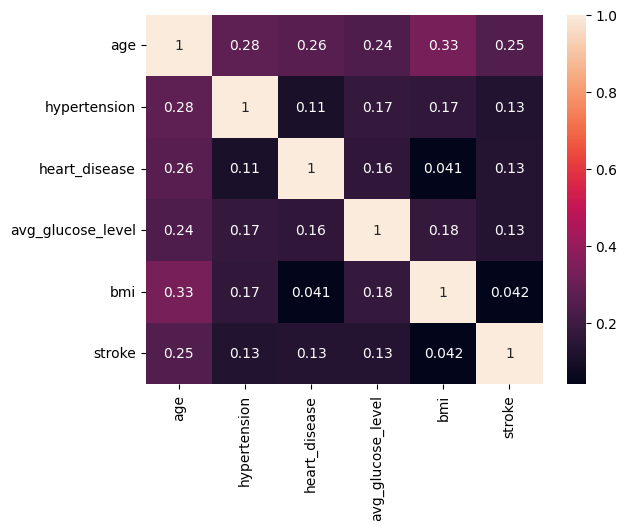

In [19]:
sns.heatmap(corr, annot = True)

split

In [20]:
target = 'stroke'
X = df.drop(columns = 'stroke')
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5110, 10)
y shape: (5110,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (4088, 10)
X_test shape: (1022, 10)
y_train shape: (4088,)
y_test shape: (1022,)


Resampling to balance the imbalance class

In [24]:
#undersampling
under_sampler = RandomUnderSampler(random_state = 42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train, y_train)
print('X_train_under shape:', X_train_under.shape)
print('y_train_under shape:', y_train_under.shape)

X_train_under shape: (374, 10)
y_train_under shape: (374,)


In [25]:
y_train_under.value_counts(normalize = True)
#

,proportion
stroke,
0,0.5
1,0.5


In [27]:
#oversampling
over_sampler = RandomOverSampler(random_state = 42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)
print('X_train_over shape:', X_train_over.shape)
print('y_train_over shape:', y_train_over.shape)

X_train_over shape: (7802, 10)
y_train_over shape: (7802,)


In [30]:
y_train_over.value_counts(normalize = True)

,proportion
stroke,
0,0.5
1,0.5


Build Mode

Baseline model

In [34]:
acc_baseline = y_train.value_counts(normalize = True).max()
print("Baseline Accuracy:", round(acc_baseline, 4))

Baseline Accuracy: 0.9543


Model Training

In [40]:
# Fit on `X_train`, `y_train`
model_reg = make_pipeline(OneHotEncoder(use_cat_names= True),
                      SimpleImputer(strategy= 'median'),
                      DecisionTreeClassifier(random_state = 42))
model_reg.fit(X_train, y_train)

# Fit on `X_train_under`, `y_train_under`
model_under = make_pipeline(OneHotEncoder(use_cat_names= True),
                      SimpleImputer(strategy= 'median'),
                      DecisionTreeClassifier(random_state = 42))
model_under.fit(X_train_under, y_train_under)

# Fit on `X_train_over`, `y_train_over`
model_over = make_pipeline(OneHotEncoder(use_cat_names= True),
                      SimpleImputer(strategy= 'median'),
                      DecisionTreeClassifier(random_state = 42))
model_over.fit(X_train_over, y_train_over)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['gender', 'ever_married', 'work_type',
                                     'Residence_type', 'smoking_status'],
                               use_cat_names=True)),
                ('simpleimputer', SimpleImputer(strategy='median')),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

In [55]:
model_reg_predict = model_reg.predict(X_train)
model_under_predict = model_under.predict(X_train)
model_over_predict = model_over.predict(X_train)

print(model_reg_predict[:10])
print(model_under_predict[:10])
print(model_over_predict[:10])

[0 0 0 0 0 0 0 0 0 0]
[1 0 0 1 0 0 1 1 0 1]
[0 0 0 0 0 0 0 0 0 0]


Actual vs Predicted values regular train model

In [56]:
results_df = pd.DataFrame({'Actual': y_train,
                           'Predicted': model_reg_predict})
results_df.head(10)

,Actual,Predicted
id,,
4970,0,0
56137,0,0
54590,0,0
36548,0,0
61171,0,0
17437,0,0
2544,0,0
26328,0,0
33123,0,0


Actual vs Predicted values under sample train model

In [63]:
results_df_under = pd.DataFrame({'Actual': y_train,
                           'Predicted': model_under_predict})
results_df_under.head(10)

,Actual,Predicted
id,,
4970,0,1
56137,0,0
54590,0,0
36548,0,1
61171,0,0
17437,0,0
2544,0,1
26328,0,1
33123,0,0


Actual vs Predicted values over train model

In [65]:
results_df_over= pd.DataFrame({'Actual': y_train,
                           'Predicted': model_over_predict})
results_df_over.head(10)

,Actual,Predicted
id,,
4970,0,0
56137,0,0
54590,0,0
36548,0,0
61171,0,0
17437,0,0
2544,0,0
26328,0,0
33123,0,0


each model on test dataset

In [66]:
model_reg_predict = model_reg.predict(X_test)
model_under_predict = model_under.predict(X_test)
model_over_predict = model_over.predict(X_test)

print(model_reg_predict[:10])
print(model_under_predict[:10])
print(model_over_predict[:10])

[0 0 0 0 0 1 0 0 0 0]
[0 0 0 0 1 1 1 1 0 0]
[0 0 0 1 0 0 0 0 0 0]


Actual vs Predicted values reg test model

In [67]:
results_df = pd.DataFrame({'Actual': y_test,
                           'Predicted': model_reg_predict})
results_df.head(10)

,Actual,Predicted
id,,
40041,0,0
55244,0,0
70992,0,0
38207,0,0
8541,0,0
2467,0,1
19828,0,0
621,0,0
54975,0,0


Actual vs Predicted values under sample test model

In [69]:
results_df = pd.DataFrame({'Actual': y_test,
                           'Predicted': model_under_predict})
results_df.head(10)

,Actual,Predicted
id,,
40041,0,0
55244,0,0
70992,0,0
38207,0,0
8541,0,1
2467,0,1
19828,0,1
621,0,1
54975,0,0


Actual vs Predicted values over sample test model

In [71]:
results_df = pd.DataFrame({'Actual': y_test,
                           'Predicted': model_over_predict})
results_df.head(10)

,Actual,Predicted
id,,
40041,0,0
55244,0,0
70992,0,0
38207,0,1
8541,0,0
2467,0,0
19828,0,0
621,0,0
54975,0,0


Evaluate

In [50]:
#accuracy_score of model_reg
model_reg_acc = model.score(X_train, y_train)
print("Model Reg Accuracy Train:", round(model_reg_acc, 4))

#accuracy_score of model_reg_test
model_reg_acc_test = model.score(X_test, y_test)
print("Model reg Accuracy Test:", round(model_reg_acc_test, 4))

#accuracy score of underresampling train
model_under_acc = model_under.score(X_train_under, y_train_under)
print("Model Under Accuracy Train:", round(model_under_acc, 4))

#accuracy score of undersampling test
model_under_acc_test = model_under.score(X_test, y_test)
print("Model Under Accuracy Test:", round(model_under_acc_test, 4))

#accuracy score of oversampling train
model_over_acc = model_over.score(X_train_over, y_train_over)
print("Model Over Accuracy Train:", round(model_over_acc, 4))

#accuracy score of oversampling test
model_over_acc_test = model_over.score(X_test, y_test)
print("Model Over Accuracy Test:", round(model_over_acc_test, 4))



Model Reg Accuracy Train: 1.0
Model reg Accuracy Test: 0.908
Model Under Accuracy Train: 1.0
Model Under Accuracy Test: 0.7045
Model Over Accuracy Train: 1.0
Model Over Accuracy Test: 0.908


Accuracy Comparison

The Regular and Over-Sampling models both achieved a high test accuracy of 90.8%.

The Under-Sampling model achieved a lower test accuracy of 70.5%.


However, accuracy alone is not a reliable metric for imbalanced datasets.

<Axes: >

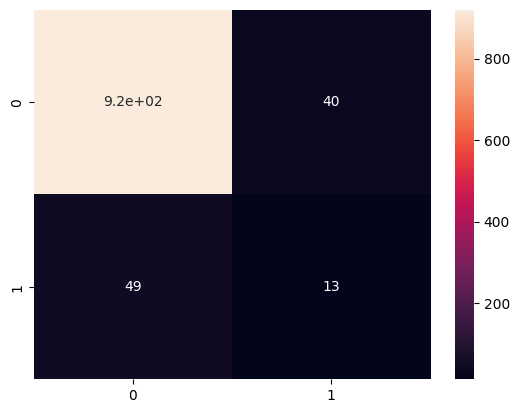

In [72]:
# Plot confusion matrix
cm = confusion_matrix(y_test, model_reg_predict)
sns.heatmap(cm, annot = True)

<Axes: >

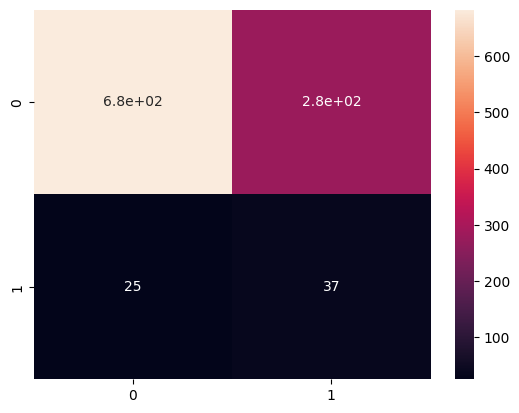

In [73]:
# Plot confusion matrix
cm = confusion_matrix(y_test, model_under_predict)
sns.heatmap(cm, annot = True)

<Axes: >

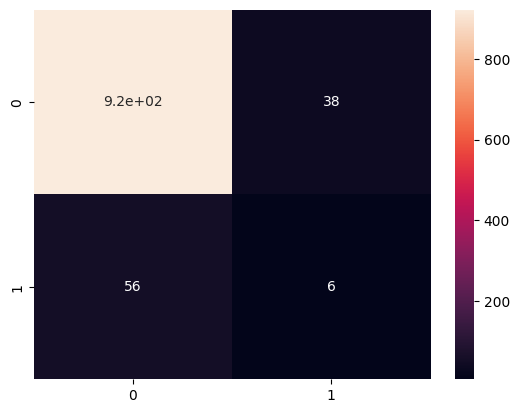

In [74]:
# Plot confusion matrix
cm = confusion_matrix(y_test, model_over_predict)
sns.heatmap(cm, annot = True)

Confusion Matrix Analysis

The Regular and Over-Sampling models correctly classified most majority-class observations but failed to detect a large proportion of the minority class, resulting in a high number of false negatives.

The Under-Sampling model showed a significantly higher number of true positives and a lower number of false negatives, indicating better detection of the minority class.


This demonstrates that the higher accuracy of the Regular and Over-Sampling models is largely due to bias toward the majority class.

Chosen Model: Under-Sampling Model

Justification:

Prioritizes recall over misleading accuracy

Detects more minority-class cases

Reduces false negatives

Better aligned with real-world decision-making in imbalanced datasets

✅ So the under-sampling model detects more positives (better recall), even if it still has some misses.

In [75]:
depth = model_over.named_steps['decisiontreeclassifier'].get_depth()
print(depth)

24


COMMUNICATION


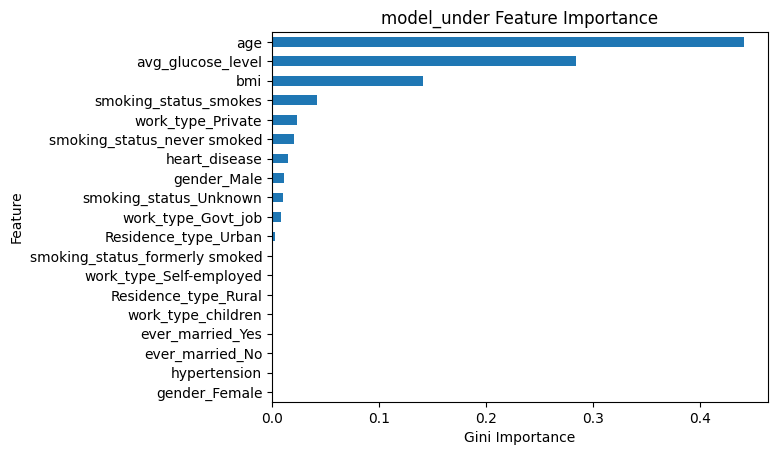

In [84]:
# Get importances
importances = model_under.named_steps['decisiontreeclassifier'].feature_importances_

# Get feature names AFTER preprocessing
feature_names = model_under.named_steps['onehotencoder'].get_feature_names_out(X_train_under.columns)

# Create Series
feat_imp = pd.Series(importances, index=feature_names).sort_values()

# Plot
feat_imp.plot(kind='barh')
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("model_under Feature Importance");

I built a model to understand which factors most influence the prediction outcome.

The Most Influential Factors  

*   Age (by far the strongest factor): Age has the biggest impact on my predictions. As age increases, the likelihood of the outcome increases significantly.  
*   Average Glucose Level: Blood sugar levels are the second most important factor in my model. Higher glucose levels are strongly associated with higher risk.
*   BMI (Body Mass Index): Weight relative to height also plays a meaningful role. Higher BMI increases the likelihood of the outcome.


 Factors With Smaller Influence  The following variables contribute to my predictions but are much less impactful:  Smoking status  

*   Work type
*   Heart disease
*   Gender
*   Residence type

These factors help me fine-tune the predictions but are not the primary drivers. My model shows that Age, glucose levels, and BMI are the main drivers of risk.  

This suggests that prevention or intervention strategies should focus primarily on Monitoring older individuals, Managing blood sugar levels, Addressing weight management

 Important Note About My Model: This version that I developed used under-sampling, meaning I reduced the majority group to balance the dataset. This approach helps the model detect minority cases better, but:  It uses less data overall  
It may be slightly less stable than other versions I have tried

